In [1]:
import os
import pandas as pd

data_dir = "./data"
processed_hourly = os.path.join(data_dir, "morpho_weth_03_processed_hourly.csv")
pool_bigquery    = os.path.join(data_dir, "morpho_weth_03_bigquery.csv")

# 1) Prices from processed-hourly, using the unnamed first column as timestamp index
dfp = pd.read_csv(processed_hourly)

# Use the first column (unnamed) as the timestamp
first_col = dfp.columns[0]
time_col = first_col  # keep exactly the first column
dfp['time'] = pd.to_datetime(dfp[time_col], utc=True, errors='coerce')
dfp = dfp.dropna(subset=['time']).set_index('time').sort_index()

# Extract requested columns exactly as stored
required_price_cols = ['quotePrice', 'token1_usd_price', 'eth_usd_price']
missing = [c for c in required_price_cols if c not in dfp.columns]
assert not missing, f"Processed hourly missing columns: {missing}"

prices = dfp[required_price_cols].astype(float).copy()
prices.index.name = 'time'

print("prices head:")
display(prices.head(5))

# 2) Full swaps from BigQuery CSV (per-swap), robust time parsing
dfs = pd.read_csv(pool_bigquery)

# Try preferred timestamp columns; otherwise auto-detect a datetime-like column
preferred_time_cols = ['block_timestamp', 'time', 'timestamp', 'datetime', 'date']
time_col_swaps = next((c for c in preferred_time_cols if c in dfs.columns), None)
if time_col_swaps is None:
    # Auto-detect: choose first column that parses to datetime for most rows
    for c in dfs.columns:
        cand = pd.to_datetime(dfs[c], utc=True, errors='coerce')
        if cand.notna().mean() > 0.8:
            time_col_swaps = c
            dfs[c] = cand  # keep parsed
            break
    if time_col_swaps is None:
        # Fallback: try first column
        time_col_swaps = dfs.columns[0]

# Ensure datetime index
dfs['time'] = pd.to_datetime(dfs[time_col_swaps], utc=True, errors='coerce')
dfs = dfs.dropna(subset=['time']).set_index('time').sort_index()

swaps_full = dfs.copy()

print("\nswaps_full head:")
display(swaps_full.head(5))

prices head:


,quotePrice,token1_usd_price,eth_usd_price
time,,,
2025-01-01 00:00:00+00:00,0.001024,3.443915,3363.70
2025-01-01 01:00:00+00:00,0.001038,3.473769,3346.54
2025-01-01 02:00:00+00:00,0.001061,3.567391,3362.61
2025-01-01 03:00:00+00:00,0.001043,3.500445,3355.20
2025-01-01 04:00:00+00:00,0.001042,3.482332,3341.14



swaps_full head:


,block_date,block_timestamp,block_number,transaction_hash,log_index,contract_address,sender,recipient,amount0,amount1,...,sqrtPriceX96_float,quotePrice,block_date.1,tick_swap,amount0_adj,amount1_adj,virtual_liquidity,virtual_liquidity_adj,token_in,traded_in
time,,,,,,,,,,,,,,,,,,,,,
2025-01-01 00:02:11+00:00,2025-01-01 00:02:11+00:00,2025-01-01 00:02:11+00:00,21525901,0xc2dbf905a0c1c47c3a4bced8c4588bb0ac8f221ab8dd...,240,0xc8219b876753a85025156b22176c2edea17aac53,0x68d3a973e7272eb388022a5c6518d9b2a2e66fbf,0x68d3a973e7272eb388022a5c6518d9b2a2e66fbf,6.615809e+20,-6.866976e+17,...,2.555252e+27,0.001040,2025-01-01 00:02:11+00:00,-68688,661.580910,-0.686698,2.437643e+22,24376.425759,token1,0.686698
2025-01-01 00:04:23+00:00,2025-01-01 00:04:23+00:00,2025-01-01 00:04:23+00:00,21525912,0xb7de8cf71527b137c7456e5c67d27a6efddfb7077ef0...,56,0xc8219b876753a85025156b22176c2edea17aac53,0x51c72848c68a965f66fa7a88855f9f7784502a7f,0x51c72848c68a965f66fa7a88855f9f7784502a7f,7.249430e+20,-7.510903e+17,...,2.552811e+27,0.001038,2025-01-01 00:04:23+00:00,-68707,724.943003,-0.751090,2.437643e+22,24376.425759,token1,0.751090
2025-01-01 00:06:23+00:00,2025-01-01 00:06:23+00:00,2025-01-01 00:06:23+00:00,21525922,0xc79ec3dc4a4182090d4fe2f4da17d022bfa8fda2ca93...,51,0xc8219b876753a85025156b22176c2edea17aac53,0x51c72848c68a965f66fa7a88855f9f7784502a7f,0x51c72848c68a965f66fa7a88855f9f7784502a7f,8.179087e+20,-8.456879e+17,...,2.550062e+27,0.001036,2025-01-01 00:06:23+00:00,-68728,817.908687,-0.845688,2.437643e+22,24376.425759,token1,0.845688
2025-01-01 00:07:35+00:00,2025-01-01 00:07:35+00:00,2025-01-01 00:07:35+00:00,21525928,0x64a12451f6c5c40c76e5aac1debbb261b9c586c2e37f...,64,0xc8219b876753a85025156b22176c2edea17aac53,0x51c72848c68a965f66fa7a88855f9f7784502a7f,0x51c72848c68a965f66fa7a88855f9f7784502a7f,7.280478e+20,-7.512445e+17,...,2.547620e+27,0.001034,2025-01-01 00:07:35+00:00,-68747,728.047791,-0.751244,2.437643e+22,24376.425759,token1,0.751244
2025-01-01 00:07:59+00:00,2025-01-01 00:07:59+00:00,2025-01-01 00:07:59+00:00,21525930,0x2f7e3a081efca1f7bc6cb471f77071beab13ff4e9717...,526,0xc8219b876753a85025156b22176c2edea17aac53,0x68d3a973e7272eb388022a5c6518d9b2a2e66fbf,0x68d3a973e7272eb388022a5c6518d9b2a2e66fbf,6.628288e+20,-6.826975e+17,...,2.545401e+27,0.001032,2025-01-01 00:07:59+00:00,-68765,662.828788,-0.682697,2.437643e+22,24376.425759,token1,0.682697


In [2]:
# 1) price_data: take the 'quote' column from prices
price_data = prices['quotePrice']

# 2) swap_data: use the full swaps as-is
swap_data = swaps_full

# 3) token_0_usd_data: take 'token1_usd_price' from prices (renamed to 'quotePrice' for compatibility)
token_0_usd_data = prices[['token1_usd_price']].rename(columns={'token1_usd_price': 'token0_usd_price'})

# Show heads
print("price_data head:")
print(price_data.head())

print("\nswap_data head:")
print(swap_data.head())

print("\ntoken_0_usd_data head:")
print(token_0_usd_data.head())

price_data head:
time
2025-01-01 00:00:00+00:00    0.001024
2025-01-01 01:00:00+00:00    0.001038
2025-01-01 02:00:00+00:00    0.001061
2025-01-01 03:00:00+00:00    0.001043
2025-01-01 04:00:00+00:00    0.001042
Name: quotePrice, dtype: float64

swap_data head:
                                          block_date  \
time                                                   
2025-01-01 00:02:11+00:00  2025-01-01 00:02:11+00:00   
2025-01-01 00:04:23+00:00  2025-01-01 00:04:23+00:00   
2025-01-01 00:06:23+00:00  2025-01-01 00:06:23+00:00   
2025-01-01 00:07:35+00:00  2025-01-01 00:07:35+00:00   
2025-01-01 00:07:59+00:00  2025-01-01 00:07:59+00:00   

                                     block_timestamp  block_number  \
time                                                                 
2025-01-01 00:02:11+00:00  2025-01-01 00:02:11+00:00      21525901   
2025-01-01 00:04:23+00:00  2025-01-01 00:04:23+00:00      21525912   
2025-01-01 00:06:23+00:00  2025-01-01 00:06:23+00:00      2152592

In [3]:
from OptimalRangeStrategy_FromSimple import OptimalRangeStrategy
from ActiveStrategyFramework import simulate_strategy, generate_simulation_series, analyze_strategy, plot_strategy, plot_position_value, plot_position_return_decomposition
import pandas as pd

# Window
start_ts = pd.Timestamp('2025-02-26 00:00:00', tz='UTC')
end_ts   = pd.Timestamp('2025-03-10 00:00:00', tz='UTC')

# Slice inputs (use exactly these columns from your prices df)
price_week = prices['quotePrice'].loc[start_ts:end_ts]
token0_usd_week = prices[['token1_usd_price']].rename(columns={'token1_usd_price':'quotePrice'}).loc[start_ts:end_ts]
swaps_week = swaps_full.loc[start_ts:end_ts]

# Volatility/correlation (from prepared file)
vol_file = "./data/pool_volatility_correlation/morpho_weth_volatility_correlation.csv"
vol_df = pd.read_csv(vol_file)
vol_df['datetime'] = pd.to_datetime(vol_df['datetime'], utc=True, errors='coerce')
vol_df = vol_df.dropna(subset=['datetime']).set_index('datetime').sort_index()
vol_week = vol_df[['cross_price_volatility','correlation']].loc[start_ts:end_ts]

print("vol_week head:")
print(vol_week.head())

# Initial 50/50 USD at t0
initial_usd = 10_000.0
t0 = price_week.index[0]
p_t0 = float(price_week.iloc[0])
p0usd_t0 = float(token0_usd_week.iloc[0, 0])  # MORPHO/USD
token1_usd_t0 = p0usd_t0 / p_t0
amt0 = (initial_usd / 2.0) / p0usd_t0
amt1 = (initial_usd / 2.0) / token1_usd_t0

# Strategy (optimal range; rebalance every 3 days)
strategy = OptimalRangeStrategy(
    volatility_data=vol_week,
    rebalance_days=1,
    alpha_range=(1.02, 2.0),
    alpha_steps=50,
    days_in_year=365
)

# Simulate
sims = simulate_strategy(
    price_data=price_week,
    swap_data=swaps_week,
    strategy_in=strategy,
    liquidity_in_0=float(amt0),
    liquidity_in_1=float(amt1),
    fee_tier=0.003,
    decimals_0=18,
    decimals_1=18,
    token_0_usd_data=token0_usd_week
)

results_opt = generate_simulation_series(sims, strategy_in=strategy, token_0_usd_data=token0_usd_week)
print(results_opt[['time','price','value_position_usd','cum_fees_usd']].head())
performance = analyze_strategy(results_opt, frequency='H')

vol_week head:
                           cross_price_volatility  correlation
datetime                                                      
2025-02-26 00:00:00+00:00                0.836419     0.784245
2025-02-26 01:00:00+00:00                0.837724     0.784430
2025-02-26 02:00:00+00:00                0.834363     0.785713
2025-02-26 03:00:00+00:00                0.825039     0.785987
2025-02-26 04:00:00+00:00                0.820390     0.783993


/Users/nicolaschiavo/Dev/tesi/univ3-strategies/ActiveStrategyFramework.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  strategy_results.append(StrategyObservation(price_data.index[i], price_data[i], strategy_in,
/Users/nicolaschiavo/Dev/tesi/univ3-strategies/ActiveStrategyFramework.py:115: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  strategy_results.append(StrategyObservation(price_data.index[i], price_data[i], strategy_in,


                       time     price  value_position_usd  cum_fees_usd
0 2025-02-26 00:00:00+00:00  0.000795        10000.000000      0.000000
1 2025-02-26 01:00:00+00:00  0.000800        10075.728335      0.677723
2 2025-02-26 02:00:00+00:00  0.000805        10156.075940      1.844025
3 2025-02-26 03:00:00+00:00  0.000808        10140.726039      2.517040
4 2025-02-26 04:00:00+00:00  0.000805        10124.303277      3.589846


/Users/nicolaschiavo/Dev/tesi/univ3-strategies/ActiveStrategyFramework.py:250: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  net_apr                 = float((strategy_last_obs['value_position_usd']/initial_position_value - 1) * 365 / days_strategy)
/Users/nicolaschiavo/Dev/tesi/univ3-strategies/ActiveStrategyFramework.py:255: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  'gross_fee_apr'        : float((strategy_last_obs['cum_fees_usd']/initial_position_value) * 365 / days_strategy),
/Users/nicolaschiavo/Dev/tesi/univ3-strategies/ActiveStrategyFramework.py:256: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  'gross_fee_return'     : float(strategy_last_obs['cum_fees_usd']/initial_position_value),


In [4]:
results_opt.to_csv('results_opt.csv')

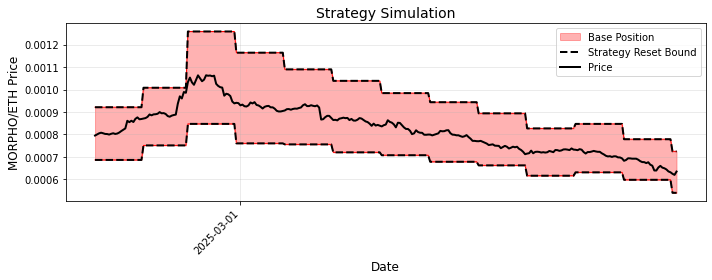

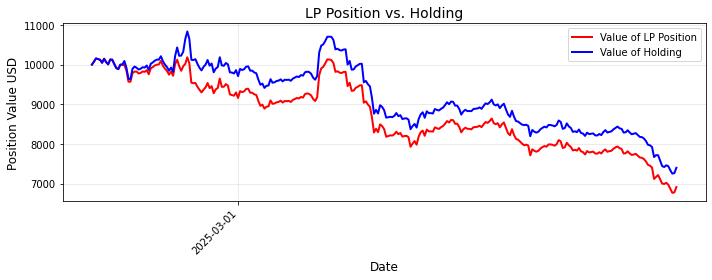

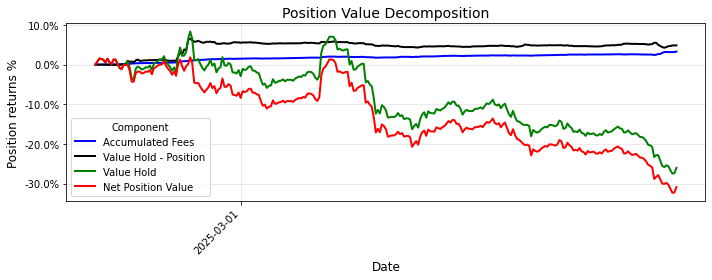

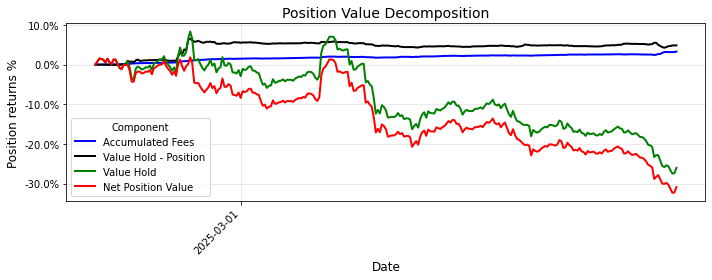

In [4]:
import pandas as pd
from ActiveStrategyFramework import (
    analyze_strategy,
    plot_strategy,
    plot_position_value,
    plot_position_return_decomposition
)


plot_strategy(results_opt, "MORPHO/ETH Price")
plot_position_value(results_opt)
plot_position_return_decomposition(results_opt)

In [5]:
# Rebalance events with optimal alpha
cols = ['time','reset_reason','optimal_alpha','price_at_reset',
        'reset_range_lower','reset_range_upper','volatility_at_reset','correlation_at_reset']

rebals = results_opt.loc[results_opt['reset_point'] == True, [c for c in cols if c in results_opt.columns]].copy()
rebals = rebals.sort_values('time')

print("Rebalances:", len(rebals))
display(rebals)

Rebalances: 12


,time,reset_reason,optimal_alpha,price_at_reset,reset_range_lower,reset_range_upper,volatility_at_reset,correlation_at_reset
24,2025-02-27 00:00:00+00:00,scheduled_rebalance,1.16,0.000871,0.000751,0.001008,0.849681,0.765784
46,2025-02-27 22:00:00+00:00,out_of_range,1.22,0.001033,0.000847,0.001259,1.279731,0.645949
70,2025-02-28 22:00:00+00:00,scheduled_rebalance,1.24,0.000941,0.000760,0.001164,1.389228,0.606125
94,2025-03-01 22:00:00+00:00,scheduled_rebalance,1.20,0.000907,0.000756,0.001090,1.151912,0.620568
118,2025-03-02 22:00:00+00:00,scheduled_rebalance,1.20,0.000864,0.000720,0.001039,1.213085,0.627340
142,2025-03-03 22:00:00+00:00,scheduled_rebalance,1.18,0.000836,0.000708,0.000984,0.998784,0.801267
166,2025-03-04 22:00:00+00:00,scheduled_rebalance,1.18,0.000800,0.000678,0.000944,1.017096,0.755958
190,2025-03-05 22:00:00+00:00,scheduled_rebalance,1.16,0.000770,0.000662,0.000894,0.870953,0.731602
214,2025-03-06 22:00:00+00:00,scheduled_rebalance,1.16,0.000715,0.000616,0.000827,0.853359,0.705729
238,2025-03-07 22:00:00+00:00,scheduled_rebalance,1.16,0.000732,0.000631,0.000847,0.816058,0.715509


In [6]:
import os, glob
base_dir = "./data/centralized_prices/futures"
files = sorted(glob.glob(os.path.join(base_dir, "*_bitget_futures_5m.csv")))
print("Found futures files:", len(files))
for p in files:
    print(os.path.basename(p))

Found futures files: 5
eth_bitget_futures_5m.csv
inj_bitget_futures_5m.csv
link_bitget_futures_5m.csv
morpho_bitget_futures_5m.csv
wtao_bitget_futures_5m.csv


In [7]:
import os
import pandas as pd
import numpy as np

_ALIAS = {
    "WETH": "ETH",  # map WETH to ETH futures
}

def load_bitget_futures_close(token_symbol: str, base_dir: str = "./data/centralized_prices/futures") -> pd.Series:
    sym = _ALIAS.get(token_symbol.upper(), token_symbol.upper()).lower()
    filename = f"{sym}_bitget_futures_5m.csv"
    path = os.path.join(base_dir, filename)
    if not os.path.exists(path):
        raise FileNotFoundError(f"Futures CSV not found: {path}")

    df = pd.read_csv(path)

    # Parse time from 'timestamp' (ms) if present, else from 'datetime'
    if 'timestamp' in df.columns and pd.api.types.is_numeric_dtype(df['timestamp']):
        idx = pd.to_datetime(df['timestamp'], unit='ms', utc=True, errors='coerce')
    elif 'datetime' in df.columns:
        idx = pd.to_datetime(df['datetime'], utc=True, errors='coerce')
    else:
        # fallback to first column
        first = df.columns[0]
        idx = pd.to_datetime(df[first], utc=True, errors='coerce')

    s = df['close'].astype(float)
    s.index = idx
    s = s[~s.index.isna()].sort_index()
    if s.index.tz is None:
        s.index = s.index.tz_localize('UTC')
    else:
        s.index = s.index.tz_convert('UTC')
    s.name = f"{sym.upper()}_fut_close"
    return s

fut0 range: 2025-01-03 17:40:00+00:00 -> 2025-08-30 13:45:00+00:00 MORPHO_fut_close
fut1 range: 2025-01-03 17:40:00+00:00 -> 2025-08-30 13:45:00+00:00 ETH_fut_close


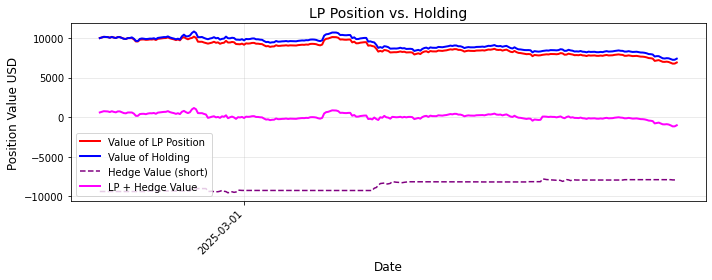

Error: Hedged value columns not found. Run hedging first.
                    time_pd  value_position_usd  hedge_value_usd  \
0 2025-02-26 00:00:00+00:00        10000.000000     -9401.999566   
1 2025-02-26 01:00:00+00:00        10075.728335     -9401.999566   
2 2025-02-26 02:00:00+00:00        10156.075940     -9401.999566   

   value_position_hedged_usd  
0                 598.000434  
1                 673.728769  
2                 754.076374  


In [8]:
from ActiveStrategyFramework import compute_hedge_series, plot_position_value, plot_pnl_unhedged_vs_hedged
import pandas as pd

# Set your pool tokens
token0 = "MORPHO"   # change to your token0
token1 = "WETH"     # change to your token1

# Load futures close series (5m)
fut0 = load_bitget_futures_close(token0)
fut1 = load_bitget_futures_close(token1)
print("fut0 range:", fut0.index.min(), "->", fut0.index.max(), fut0.name)
print("fut1 range:", fut1.index.min(), "->", fut1.index.max(), fut1.name)

# Load strategy results if not already in memory as `res`
if 'res' not in globals():
    results_path = "./results_opt.csv"  # or your file
    res = pd.read_csv(results_path)
    # Ensure a proper datetime column
    if 'time_pd' in res.columns:
        res['time_pd'] = pd.to_datetime(res['time_pd'], utc=True, errors='coerce')
    else:
        res['time_pd'] = pd.to_datetime(res['time'], utc=True, errors='coerce')
    res = res.dropna(subset=['time_pd']).sort_values('time_pd')

# Compute hedge series (re-hedge on reset points)
res_hedge = compute_hedge_series(res, futures_price_0_usd=fut0, futures_price_1_usd=fut1, adjust_on_reset=True)

# Plot LP vs Hold vs Hedge vs LP+Hedge
_ = plot_position_value(res_hedge)
_ = plot_pnl_unhedged_vs_hedged(res_hedge)

# Quick sanity check on hedge columns
print(res_hedge[['time_pd','value_position_usd','hedge_value_usd','value_position_hedged_usd']].head(3))

Error: Hedged value columns not found. Run hedging first.


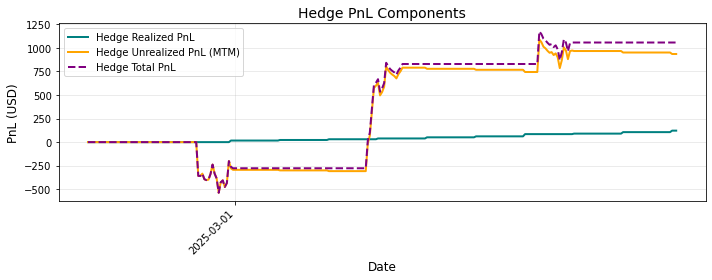

In [9]:
from ActiveStrategyFramework import plot_pnl_unhedged_vs_hedged, plot_hedge_pnl_components

_ = plot_pnl_unhedged_vs_hedged(res_hedge)
_ = plot_hedge_pnl_components(res_hedge)